# Continued Process Verification (CPV) Analytics
## Synthetic Oral Solid Dosage Case Study

This notebook demonstrates a Python-based CPV workflow using synthetic manufacturing data. The analysis distinguishes specification compliance from statistical process behavior, identifies coordinated process signals, and prioritizes variables for investigation without claiming causality.


## 1. Data Import and Initial Inspection
Load the synthetic dataset and review its structure, summary statistics, reference-period split, and batch-level dissolution results.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("CPV_Synthetic_Source_Data.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (24, 13)


In [2]:
df.describe()

,API_PSD_D90_um,Compression_Force_kN,Tablet_Hardness_kp,Thickness_mm,Tablet_Weight_mg,Disintegration_min,Dissolution_30min_pct
count,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,79.166667,11.345833,7.500000,4.203750,500.458333,6.970833,91.916667
std,7.251187,0.991696,0.716271,0.010959,1.413573,0.876990,4.179834
min,71.000000,10.200000,6.700000,4.180000,498.000000,6.100000,82.000000
25%,74.750000,10.675000,7.000000,4.200000,499.750000,6.400000,91.500000
50%,76.000000,11.000000,7.250000,4.200000,500.000000,6.650000,93.500000
75%,81.750000,11.675000,7.625000,4.210000,501.250000,7.025000,95.000000
max,92.000000,13.300000,9.200000,4.220000,503.000000,9.200000,96.000000


In [3]:
df["Reference_Period"].value_counts()      

Reference_Period
Historical    18
Monitoring     6
Name: count, dtype: int64

In [4]:
df[["Batch_ID", "Dissolution_30min_pct"]]

,Batch_ID,Dissolution_30min_pct
0,B001,95
1,B002,94
2,B003,96
3,B004,93
4,B005,95
5,B006,94
6,B007,96
7,B008,95
8,B009,94
9,B010,93


## 2. Initial Dissolution Trend
Visualize batch-to-batch dissolution performance before applying historical-reference limits.


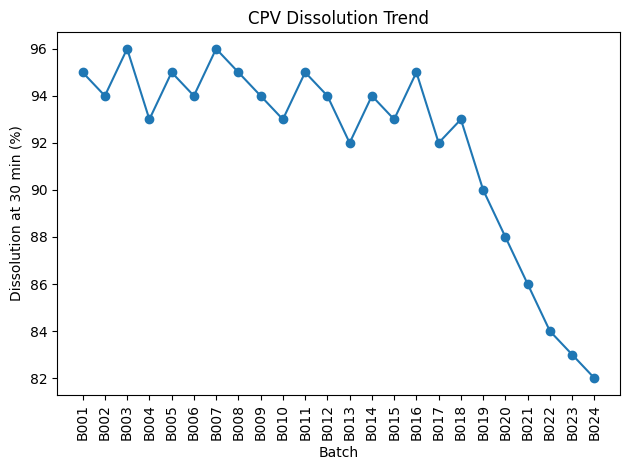

In [5]:

plt.plot(df["Batch_ID"], df["Dissolution_30min_pct"], marker="o")
plt.xticks(rotation=90)
plt.xlabel("Batch")
plt.ylabel("Dissolution at 30 min (%)")
plt.title("CPV Dissolution Trend")
plt.tight_layout()
plt.show()

## 3. Historical Reference and Provisional Control Limits
Use B001–B018 as the historical reference period, then calculate the historical mean, standard deviation, and provisional ±3 SD limits for dissolution.


In [6]:
historical = df[df["Reference_Period"] == "Historical"]
monitoring = df[df["Reference_Period"] == "Monitoring"]

In [7]:
historical_mean = historical["Dissolution_30min_pct"].mean()
monitoring_mean = monitoring["Dissolution_30min_pct"].mean()

historical_mean, monitoring_mean

(np.float64(94.05555555555556), np.float64(85.5))

In [8]:
historical_std = historical["Dissolution_30min_pct"].std()

historical_std

np.float64(1.2113299556429322)

In [9]:
ucl = historical_mean + 3 * historical_std
lcl = historical_mean - 3 * historical_std

ucl, lcl

(np.float64(97.68954542248436), np.float64(90.42156568862676))

In [10]:
df["Control_Status"] = df["Dissolution_30min_pct"].apply(
lambda x: "Below LCL" if x < lcl
else "Above UCL" if x > ucl
else "Within Limits"
)

df[["Batch_ID", "Dissolution_30min_pct", "Control_Status"]]

,Batch_ID,Dissolution_30min_pct,Control_Status
0,B001,95,Within Limits
1,B002,94,Within Limits
2,B003,96,Within Limits
3,B004,93,Within Limits
4,B005,95,Within Limits
5,B006,94,Within Limits
6,B007,96,Within Limits
7,B008,95,Within Limits
8,B009,94,Within Limits
9,B010,93,Within Limits


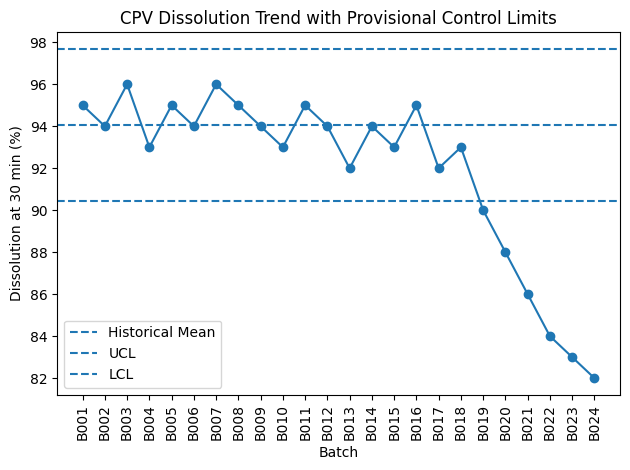

In [11]:

plt.plot(df["Batch_ID"], df["Dissolution_30min_pct"], marker="o")
plt.axhline(historical_mean, linestyle="--", label="Historical Mean")
plt.axhline(ucl, linestyle="--", label="UCL")
plt.axhline(lcl, linestyle="--", label="LCL")

plt.xticks(rotation=90)
plt.xlabel("Batch")
plt.ylabel("Dissolution at 30 min (%)")
plt.title("CPV Dissolution Trend with Provisional Control Limits")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Dissolution Signal Detection
Classify each batch relative to the historical dissolution limits and distinguish statistical process signals from specification status.


In [12]:
df["Dissolution_Signal"] = "Normal"

df.loc[df["Dissolution_30min_pct"] > ucl, "Dissolution_Signal"] = "Above UCL"
df.loc[df["Dissolution_30min_pct"] < lcl, "Dissolution_Signal"] = "Below LCL"

df[["Batch_ID", "Reference_Period", "Dissolution_30min_pct", "Dissolution_Signal"]]

,Batch_ID,Reference_Period,Dissolution_30min_pct,Dissolution_Signal
0,B001,Historical,95,Normal
1,B002,Historical,94,Normal
2,B003,Historical,96,Normal
3,B004,Historical,93,Normal
4,B005,Historical,95,Normal
5,B006,Historical,94,Normal
6,B007,Historical,96,Normal
7,B008,Historical,95,Normal
8,B009,Historical,94,Normal
9,B010,Historical,93,Normal


In [13]:
df.columns.tolist()

['Batch_ID',
 'Manufacture_Date',
 'Product',
 'Reference_Period',
 'API_Lot',
 'API_PSD_D90_um',
 'Compression_Force_kN',
 'Tablet_Hardness_kp',
 'Thickness_mm',
 'Tablet_Weight_mg',
 'Disintegration_min',
 'Dissolution_30min_pct',
 'Spec_Status',
 'Control_Status',
 'Dissolution_Signal']

In [14]:
df.loc[
    df["Reference_Period"] == "Monitoring",
    ["Batch_ID", "Dissolution_30min_pct", "Spec_Status", "Dissolution_Signal"]
]

,Batch_ID,Dissolution_30min_pct,Spec_Status,Dissolution_Signal
18,B019,90,Pass,Below LCL
19,B020,88,Pass,Below LCL
20,B021,86,Pass,Below LCL
21,B022,84,Pass,Below LCL
22,B023,83,Pass,Below LCL
23,B024,82,Pass,Below LCL


## 5. Monitoring-Period Process Relationships
Review monitoring-batch material and process parameters, quantify correlations with dissolution, and visualize the compression-force relationship. Correlation is used for investigation prioritization only and does not establish causality.


In [15]:
df.loc[
    df["Reference_Period"] == "Monitoring",
    [
        "Batch_ID",
        "API_PSD_D90_um",
        "Compression_Force_kN",
        "Tablet_Hardness_kp",
        "Disintegration_min",
        "Dissolution_30min_pct"
    ]
]

,Batch_ID,API_PSD_D90_um,Compression_Force_kN,Tablet_Hardness_kp,Disintegration_min,Dissolution_30min_pct
18,B019,90,12.5,8.0,7.4,90
19,B020,91,12.7,8.3,7.8,88
20,B021,90,12.9,8.5,8.1,86
21,B022,92,13.0,8.7,8.5,84
22,B023,91,13.2,9.0,8.9,83
23,B024,92,13.3,9.2,9.2,82


In [16]:
monitoring_cols = [
    "API_PSD_D90_um",
    "Compression_Force_kN",
    "Tablet_Hardness_kp",
    "Disintegration_min",
    "Dissolution_30min_pct"
]

df.loc[
    df["Reference_Period"] == "Monitoring",
    monitoring_cols
].corr()["Dissolution_30min_pct"].sort_values()

Compression_Force_kN    -0.991293
Disintegration_min      -0.988426
Tablet_Hardness_kp      -0.985157
API_PSD_D90_um          -0.725476
Dissolution_30min_pct    1.000000
Name: Dissolution_30min_pct, dtype: float64

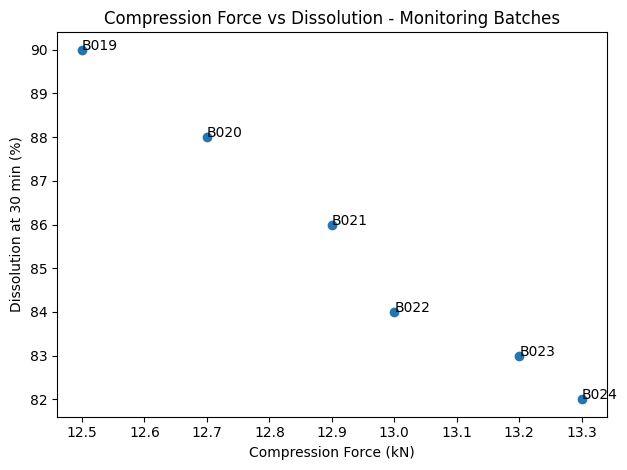

In [17]:
monitoring_df = df[df["Reference_Period"] == "Monitoring"]

plt.scatter(
    monitoring_df["Compression_Force_kN"],
    monitoring_df["Dissolution_30min_pct"]
)

for _, row in monitoring_df.iterrows():
    plt.annotate(
        row["Batch_ID"],
        (row["Compression_Force_kN"], row["Dissolution_30min_pct"])
    )

plt.xlabel("Compression Force (kN)")
plt.ylabel("Dissolution at 30 min (%)")
plt.title("Compression Force vs Dissolution - Monitoring Batches")
plt.tight_layout()
plt.show()

## 6. Process-Parameter and Intermediate-Response Signals
Compare compression force, tablet hardness, and disintegration against historical behavior and create statistical signal flags.


In [18]:
cf_hist = df.loc[
    df["Reference_Period"] == "Historical",
    "Compression_Force_kN"
]

cf_mean = cf_hist.mean()
cf_std = cf_hist.std()

cf_ucl = cf_mean + 3 * cf_std
cf_lcl = cf_mean - 3 * cf_std

print("Historical Compression Force Mean:", round(cf_mean, 2))
print("Compression Force UCL:", round(cf_ucl, 2))
print("Compression Force LCL:", round(cf_lcl, 2))

df.loc[
    df["Reference_Period"] == "Monitoring",
    ["Batch_ID", "Compression_Force_kN"]
]

Historical Compression Force Mean: 10.82
Compression Force UCL: 11.85
Compression Force LCL: 9.79


,Batch_ID,Compression_Force_kN
18,B019,12.5
19,B020,12.7
20,B021,12.9
21,B022,13.0
22,B023,13.2
23,B024,13.3


In [19]:
df["Compression_Signal"] = "Normal"

df.loc[
    df["Compression_Force_kN"] > cf_ucl,
    "Compression_Signal"
] = "Above UCL"

df.loc[
    df["Compression_Force_kN"] < cf_lcl,
    "Compression_Signal"
] = "Below LCL"

df.loc[
    df["Reference_Period"] == "Monitoring",
    ["Batch_ID", "Compression_Force_kN", "Compression_Signal"]
]

,Batch_ID,Compression_Force_kN,Compression_Signal
18,B019,12.5,Above UCL
19,B020,12.7,Above UCL
20,B021,12.9,Above UCL
21,B022,13.0,Above UCL
22,B023,13.2,Above UCL
23,B024,13.3,Above UCL


In [20]:
hardness_hist = df.loc[
    df["Reference_Period"] == "Historical",
    "Tablet_Hardness_kp"
]

disint_hist = df.loc[
    df["Reference_Period"] == "Historical",
    "Disintegration_min"
]

hardness_ucl = hardness_hist.mean() + 3 * hardness_hist.std()
hardness_lcl = hardness_hist.mean() - 3 * hardness_hist.std()

disint_ucl = disint_hist.mean() + 3 * disint_hist.std()
disint_lcl = disint_hist.mean() - 3 * disint_hist.std()

print("Hardness Mean:", round(hardness_hist.mean(), 2))
print("Hardness UCL:", round(hardness_ucl, 2))
print("Hardness LCL:", round(hardness_lcl, 2))

print()

print("Disintegration Mean:", round(disint_hist.mean(), 2))
print("Disintegration UCL:", round(disint_ucl, 2))
print("Disintegration LCL:", round(disint_lcl, 2))

Hardness Mean: 7.13
Hardness UCL: 7.79
Hardness LCL: 6.46

Disintegration Mean: 6.52
Disintegration UCL: 7.21
Disintegration LCL: 5.84


In [21]:
df["Hardness_Signal"] = "Normal"
df["Disintegration_Signal"] = "Normal"

df.loc[
    df["Tablet_Hardness_kp"] > hardness_ucl,
    "Hardness_Signal"
] = "Above UCL"

df.loc[
    df["Disintegration_min"] > disint_ucl,
    "Disintegration_Signal"
] = "Above UCL"

df.loc[
    df["Reference_Period"] == "Monitoring",
    [
        "Batch_ID",
        "Compression_Signal",
        "Hardness_Signal",
        "Disintegration_Signal",
        "Dissolution_Signal"
    ]
]

,Batch_ID,Compression_Signal,Hardness_Signal,Disintegration_Signal,Dissolution_Signal
18,B019,Above UCL,Above UCL,Above UCL,Below LCL
19,B020,Above UCL,Above UCL,Above UCL,Below LCL
20,B021,Above UCL,Above UCL,Above UCL,Below LCL
21,B022,Above UCL,Above UCL,Above UCL,Below LCL
22,B023,Above UCL,Above UCL,Above UCL,Below LCL
23,B024,Above UCL,Above UCL,Above UCL,Below LCL


## 7. Multivariate Signal Summary and KPI Layer
Combine individual statistical flags into a batch-level signal count, CPV status, signal matrix, and monitoring KPIs.


In [22]:
signal_cols = [
    "Compression_Signal",
    "Hardness_Signal",
    "Disintegration_Signal",
    "Dissolution_Signal"
]

df["Signal_Count"] = df[signal_cols].ne("Normal").sum(axis=1)

df["CPV_Status"] = "Stable"

df.loc[
    (df["Spec_Status"] == "Pass") & (df["Signal_Count"] > 0),
    "CPV_Status"
] = "Pass - Process Signal"

df.loc[
    df["Reference_Period"] == "Monitoring",
    [
        "Batch_ID",
        "Dissolution_30min_pct",
        "Spec_Status",
        "Signal_Count",
        "CPV_Status"
    ]
]

,Batch_ID,Dissolution_30min_pct,Spec_Status,Signal_Count,CPV_Status
18,B019,90,Pass,4,Pass - Process Signal
19,B020,88,Pass,4,Pass - Process Signal
20,B021,86,Pass,4,Pass - Process Signal
21,B022,84,Pass,4,Pass - Process Signal
22,B023,83,Pass,4,Pass - Process Signal
23,B024,82,Pass,4,Pass - Process Signal


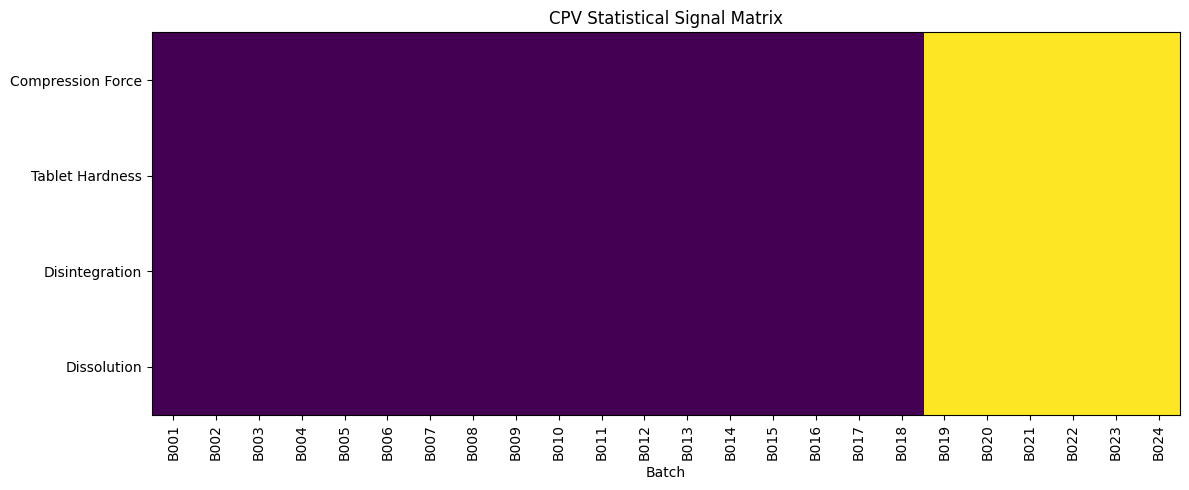

In [23]:
signal_matrix = df[
    [
        "Compression_Signal",
        "Hardness_Signal",
        "Disintegration_Signal",
        "Dissolution_Signal"
    ]
].ne("Normal").astype(int)

fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(signal_matrix.T, aspect="auto")

ax.set_xticks(range(len(df)))
ax.set_xticklabels(df["Batch_ID"], rotation=90)

ax.set_yticks(range(4))
ax.set_yticklabels([
    "Compression Force",
    "Tablet Hardness",
    "Disintegration",
    "Dissolution"
])

ax.set_xlabel("Batch")
ax.set_title("CPV Statistical Signal Matrix")

plt.tight_layout()
plt.show()

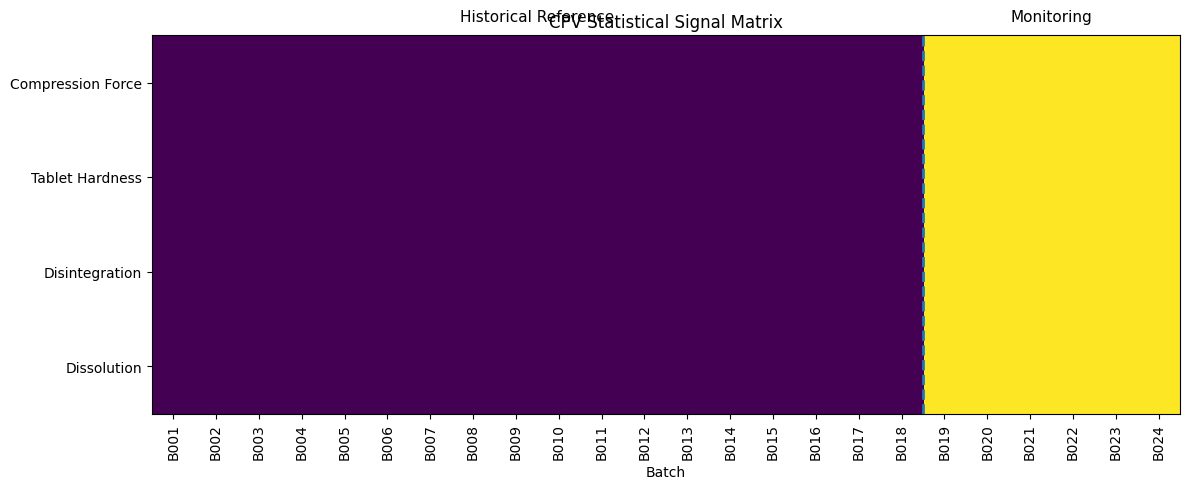

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(signal_matrix.T, aspect="auto")

ax.set_xticks(range(len(df)))
ax.set_xticklabels(df["Batch_ID"], rotation=90)

ax.set_yticks(range(4))
ax.set_yticklabels([
    "Compression Force",
    "Tablet Hardness",
    "Disintegration",
    "Dissolution"
])

# Mark transition between B018 and B019
ax.axvline(x=17.5, linestyle="--", linewidth=2)

ax.text(
    8.5, -0.65,
    "Historical Reference",
    ha="center",
    fontsize=11
)

ax.text(
    20.5, -0.65,
    "Monitoring",
    ha="center",
    fontsize=11
)

ax.set_xlabel("Batch")
ax.set_title("CPV Statistical Signal Matrix")

plt.tight_layout()
plt.show()

In [25]:
monitoring_df = df[df["Reference_Period"] == "Monitoring"]

total_monitoring = len(monitoring_df)

flagged_batches = (
    monitoring_df["CPV_Status"] == "Pass - Process Signal"
).sum()

spec_failures = (
    monitoring_df["Spec_Status"] != "Pass"
).sum()

avg_signal_count = monitoring_df["Signal_Count"].mean()

print("Monitoring Batches:", total_monitoring)
print("Batches with CPV Signals:", flagged_batches)
print("Specification Failures:", spec_failures)
print("Average Signals per Batch:", round(avg_signal_count, 1))

Monitoring Batches: 6
Batches with CPV Signals: 6
Specification Failures: 0
Average Signals per Batch: 4.0


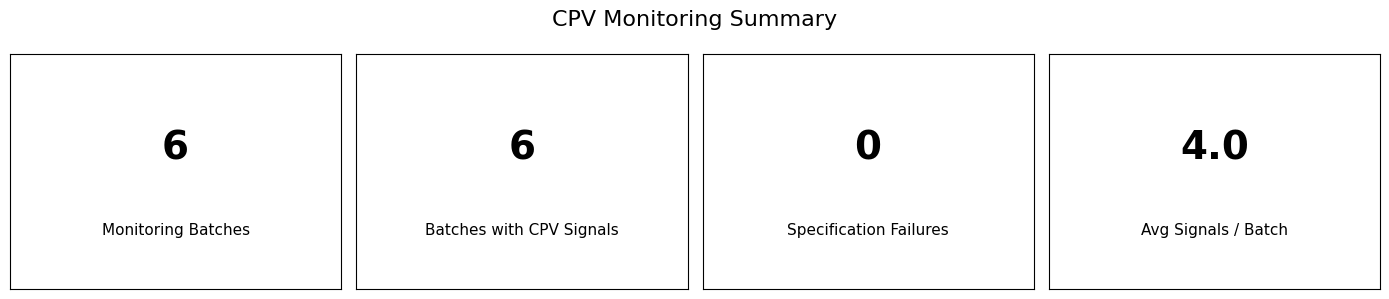

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

kpi_values = [
    total_monitoring,
    flagged_batches,
    spec_failures,
    round(avg_signal_count, 1)
]

kpi_titles = [
    "Monitoring Batches",
    "Batches with CPV Signals",
    "Specification Failures",
    "Avg Signals / Batch"
]

for ax, value, title in zip(axes, kpi_values, kpi_titles):
    ax.text(
        0.5, 0.6,
        str(value),
        ha="center",
        va="center",
        fontsize=28,
        fontweight="bold"
    )

    ax.text(
        0.5, 0.25,
        title,
        ha="center",
        va="center",
        fontsize=11
    )

    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("CPV Monitoring Summary", fontsize=16)
plt.tight_layout()
plt.show()

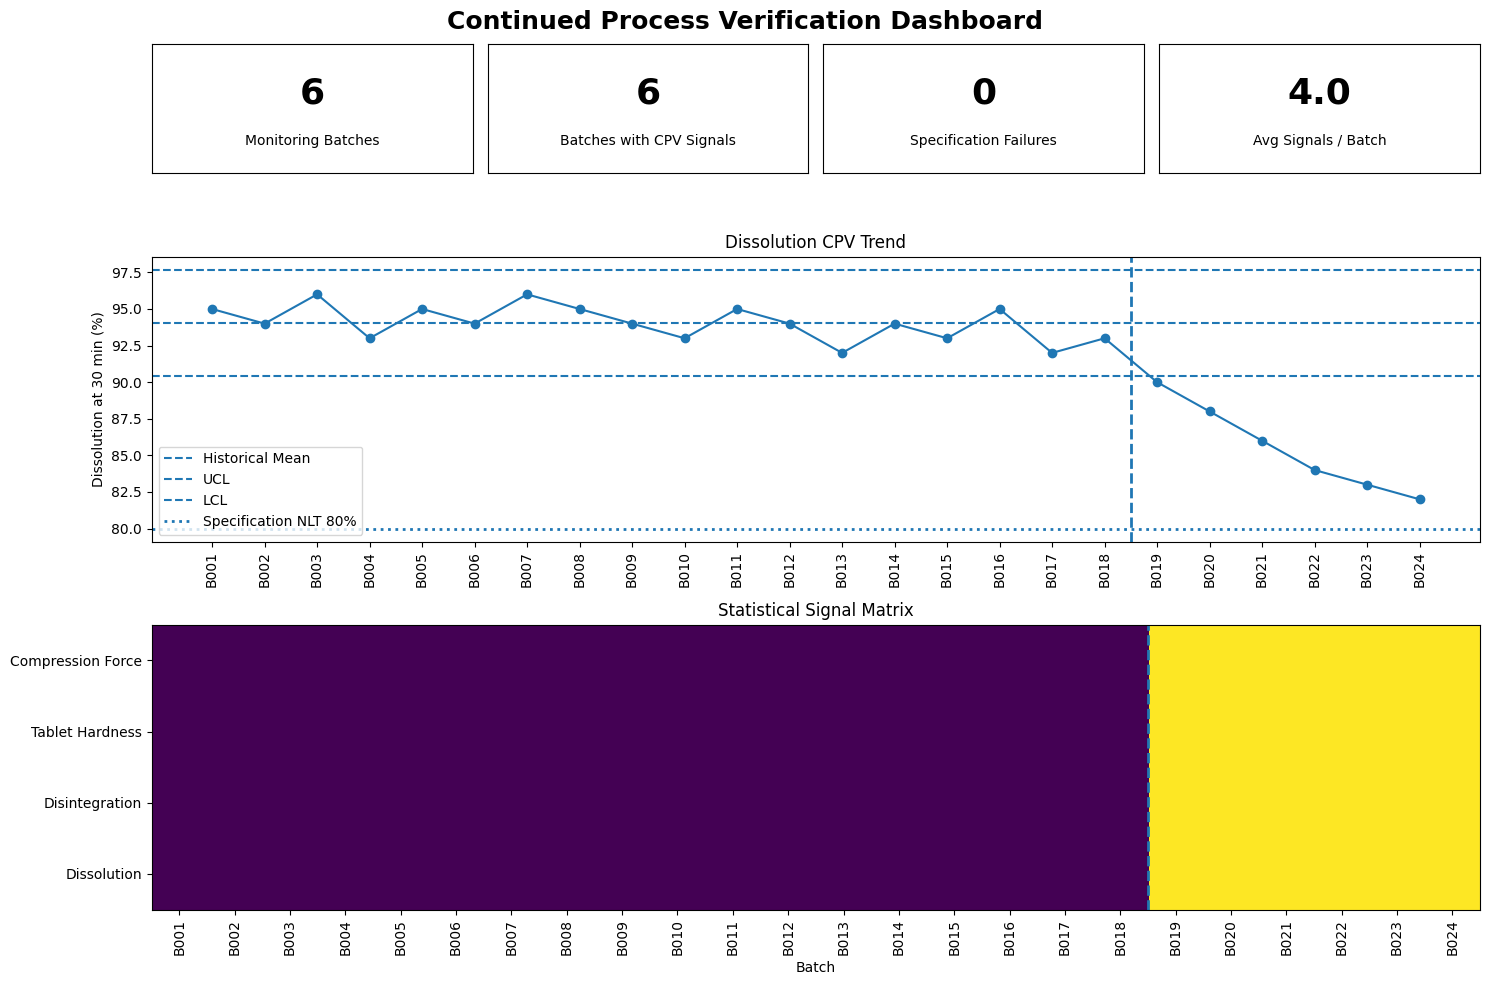

In [27]:
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(3, 4, height_ratios=[1, 2.2, 2.2])

# -------------------------------------------------
# 1. KPI CARDS
# -------------------------------------------------

kpi_values = [
    total_monitoring,
    flagged_batches,
    spec_failures,
    round(avg_signal_count, 1)
]

kpi_titles = [
    "Monitoring Batches",
    "Batches with CPV Signals",
    "Specification Failures",
    "Avg Signals / Batch"
]

for i in range(4):
    ax = fig.add_subplot(gs[0, i])

    ax.text(
        0.5, 0.62,
        str(kpi_values[i]),
        ha="center",
        va="center",
        fontsize=26,
        fontweight="bold"
    )

    ax.text(
        0.5, 0.25,
        kpi_titles[i],
        ha="center",
        va="center",
        fontsize=10
    )

    ax.set_xticks([])
    ax.set_yticks([])


# -------------------------------------------------
# 2. DISSOLUTION TREND
# -------------------------------------------------

ax1 = fig.add_subplot(gs[1, :])

ax1.plot(
    df["Batch_ID"],
    df["Dissolution_30min_pct"],
    marker="o"
)

ax1.axhline(
    historical_mean,
    linestyle="--",
    label="Historical Mean"
)

ax1.axhline(
    ucl,
    linestyle="--",
    label="UCL"
)

ax1.axhline(
    lcl,
    linestyle="--",
    label="LCL"
)

# Product specification
ax1.axhline(
    80,
    linestyle=":",
    linewidth=2,
    label="Specification NLT 80%"
)

# Historical → Monitoring boundary
ax1.axvline(
    x=17.5,
    linestyle="--",
    linewidth=2
)

ax1.set_ylabel("Dissolution at 30 min (%)")
ax1.set_title("Dissolution CPV Trend")
ax1.tick_params(axis="x", rotation=90)
ax1.legend()


# -------------------------------------------------
# 3. SIGNAL MATRIX
# -------------------------------------------------

ax2 = fig.add_subplot(gs[2, :])

ax2.imshow(
    signal_matrix.T,
    aspect="auto"
)

ax2.set_xticks(range(len(df)))
ax2.set_xticklabels(
    df["Batch_ID"],
    rotation=90
)

ax2.set_yticks(range(4))
ax2.set_yticklabels([
    "Compression Force",
    "Tablet Hardness",
    "Disintegration",
    "Dissolution"
])

ax2.axvline(
    x=17.5,
    linestyle="--",
    linewidth=2
)

ax2.set_xlabel("Batch")
ax2.set_title("Statistical Signal Matrix")


# -------------------------------------------------
# OVERALL DASHBOARD TITLE
# -------------------------------------------------

fig.suptitle(
    "Continued Process Verification Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 8. Risk Classification and Automated CPV Assessment
Apply a simple project-specific triage layer to summarize the severity of coordinated process signals. These Green/Yellow/Red/Critical labels are project rules, not regulatory categories.


In [28]:
df["Risk_Level"] = "Green"

df.loc[
    (df["Signal_Count"] >= 1) & (df["Signal_Count"] <= 2),
    "Risk_Level"
] = "Yellow"

df.loc[
    df["Signal_Count"] >= 3,
    "Risk_Level"
] = "Red"

df.loc[
    df["Spec_Status"] != "Pass",
    "Risk_Level"
] = "Critical"

df.loc[
    df["Reference_Period"] == "Monitoring",
    [
        "Batch_ID",
        "Spec_Status",
        "Signal_Count",
        "CPV_Status",
        "Risk_Level"
    ]
]

,Batch_ID,Spec_Status,Signal_Count,CPV_Status,Risk_Level
18,B019,Pass,4,Pass - Process Signal,Red
19,B020,Pass,4,Pass - Process Signal,Red
20,B021,Pass,4,Pass - Process Signal,Red
21,B022,Pass,4,Pass - Process Signal,Red
22,B023,Pass,4,Pass - Process Signal,Red
23,B024,Pass,4,Pass - Process Signal,Red


In [29]:
monitoring_df = df[df["Reference_Period"] == "Monitoring"]

red_batches = (monitoring_df["Risk_Level"] == "Red").sum()
critical_batches = (monitoring_df["Risk_Level"] == "Critical").sum()
total_monitoring = len(monitoring_df)

if critical_batches > 0:
    cpv_conclusion = (
        f"Immediate escalation recommended: "
        f"{critical_batches} monitoring batch(es) failed specification."
    )

elif red_batches >= 3:
    cpv_conclusion = (
        f"Escalation recommended: sustained multivariate process shift detected "
        f"across {red_batches} of {total_monitoring} monitoring batches "
        f"despite continued specification compliance."
    )

elif red_batches > 0:
    cpv_conclusion = (
        "Process review recommended: multiple statistical signals detected "
        "during continued process verification."
    )

else:
    cpv_conclusion = (
        "Process remains consistent with the historical reference state."
    )

print("CPV Conclusion:")
print(cpv_conclusion)

CPV Conclusion:
Escalation recommended: sustained multivariate process shift detected across 6 of 6 monitoring batches despite continued specification compliance.


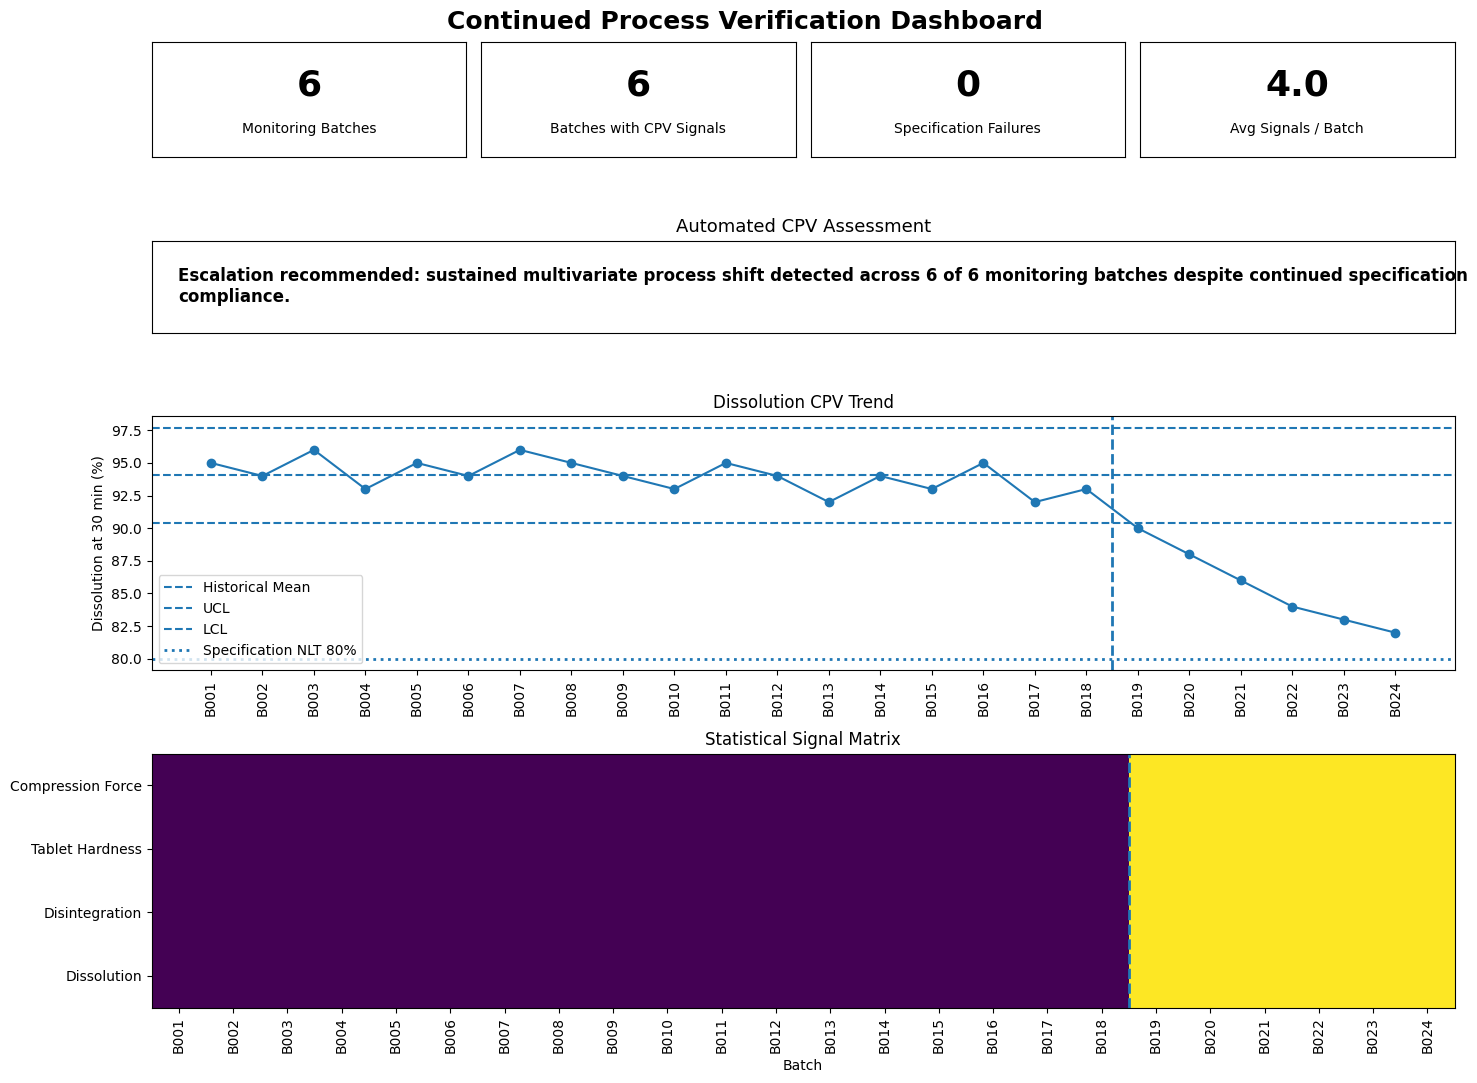

In [30]:
fig = plt.figure(figsize=(15, 11))
gs = fig.add_gridspec(
    4, 4,
    height_ratios=[1, 0.8, 2.2, 2.2]
)

# -------------------------------------------------
# 1. KPI CARDS
# -------------------------------------------------

kpi_values = [
    total_monitoring,
    flagged_batches,
    spec_failures,
    round(avg_signal_count, 1)
]

kpi_titles = [
    "Monitoring Batches",
    "Batches with CPV Signals",
    "Specification Failures",
    "Avg Signals / Batch"
]

for i in range(4):
    ax = fig.add_subplot(gs[0, i])

    ax.text(
        0.5, 0.62,
        str(kpi_values[i]),
        ha="center",
        va="center",
        fontsize=26,
        fontweight="bold"
    )

    ax.text(
        0.5, 0.25,
        kpi_titles[i],
        ha="center",
        va="center",
        fontsize=10
    )

    ax.set_xticks([])
    ax.set_yticks([])


# -------------------------------------------------
# 2. AUTOMATED CPV CONCLUSION
# -------------------------------------------------

ax0 = fig.add_subplot(gs[1, :])

ax0.text(
    0.02,
    0.5,
    cpv_conclusion,
    ha="left",
    va="center",
    fontsize=12,
    fontweight="bold",
    wrap=True
)

ax0.set_title("Automated CPV Assessment", fontsize=13)
ax0.set_xticks([])
ax0.set_yticks([])


# -------------------------------------------------
# 3. DISSOLUTION TREND
# -------------------------------------------------

ax1 = fig.add_subplot(gs[2, :])

ax1.plot(
    df["Batch_ID"],
    df["Dissolution_30min_pct"],
    marker="o"
)

ax1.axhline(
    historical_mean,
    linestyle="--",
    label="Historical Mean"
)

ax1.axhline(
    ucl,
    linestyle="--",
    label="UCL"
)

ax1.axhline(
    lcl,
    linestyle="--",
    label="LCL"
)

ax1.axhline(
    80,
    linestyle=":",
    linewidth=2,
    label="Specification NLT 80%"
)

ax1.axvline(
    x=17.5,
    linestyle="--",
    linewidth=2
)

ax1.set_ylabel("Dissolution at 30 min (%)")
ax1.set_title("Dissolution CPV Trend")
ax1.tick_params(axis="x", rotation=90)
ax1.legend()


# -------------------------------------------------
# 4. SIGNAL MATRIX
# -------------------------------------------------

ax2 = fig.add_subplot(gs[3, :])

ax2.imshow(
    signal_matrix.T,
    aspect="auto"
)

ax2.set_xticks(range(len(df)))
ax2.set_xticklabels(
    df["Batch_ID"],
    rotation=90
)

ax2.set_yticks(range(4))
ax2.set_yticklabels([
    "Compression Force",
    "Tablet Hardness",
    "Disintegration",
    "Dissolution"
])

ax2.axvline(
    x=17.5,
    linestyle="--",
    linewidth=2
)

ax2.set_xlabel("Batch")
ax2.set_title("Statistical Signal Matrix")


# -------------------------------------------------
# DASHBOARD TITLE
# -------------------------------------------------

fig.suptitle(
    "Continued Process Verification Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 9. Standardized Shift Analysis and Investigation Prioritization
Standardize monitoring-batch departures from the historical reference using z-scores, quantify shift severity, and separate upstream investigation variables from intermediate responses and the CQA.


In [31]:
root_cause_vars = [
    "Compression_Force_kN",
    "Tablet_Hardness_kp",
    "Disintegration_min",
    "API_PSD_D90_um"
]

historical_df = df[df["Reference_Period"] == "Historical"]
monitoring_df = df[df["Reference_Period"] == "Monitoring"]

root_cause_summary = []

for var in root_cause_vars:
    
    hist_mean = historical_df[var].mean()
    monitoring_mean = monitoring_df[var].mean()
    
    pct_change = ((monitoring_mean - hist_mean) / hist_mean) * 100
    
    correlation = monitoring_df[
        [var, "Dissolution_30min_pct"]
    ].corr().iloc[0, 1]
    
    root_cause_summary.append({
        "Parameter": var,
        "Historical_Mean": round(hist_mean, 2),
        "Monitoring_Mean": round(monitoring_mean, 2),
        "Percent_Change": round(pct_change, 1),
        "Correlation_with_Dissolution": round(correlation, 3)
    })

root_cause_summary = pd.DataFrame(root_cause_summary)

root_cause_summary

,Parameter,Historical_Mean,Monitoring_Mean,Percent_Change,Correlation_with_Dissolution
0,Compression_Force_kN,10.82,12.93,19.6,-0.991
1,Tablet_Hardness_kp,7.13,8.62,20.9,-0.985
2,Disintegration_min,6.52,8.32,27.5,-0.988
3,API_PSD_D90_um,75.22,91.00,21.0,-0.725


In [32]:
monitoring_df[
    [
        "API_PSD_D90_um",
        "Compression_Force_kN",
        "Tablet_Hardness_kp",
        "Disintegration_min",
        "Dissolution_30min_pct"
    ]
].corr()

,API_PSD_D90_um,Compression_Force_kN,Tablet_Hardness_kp,Disintegration_min,Dissolution_30min_pct
API_PSD_D90_um,1.000000,0.668350,0.704119,0.724008,-0.725476
Compression_Force_kN,0.668350,1.000000,0.995974,0.993849,-0.991293
Tablet_Hardness_kp,0.704119,0.995974,1.000000,0.998611,-0.985157
Disintegration_min,0.724008,0.993849,0.998611,1.000000,-0.988426
Dissolution_30min_pct,-0.725476,-0.991293,-0.985157,-0.988426,1.000000


In [33]:
variables = [
    "API_PSD_D90_um",
    "Compression_Force_kN",
    "Tablet_Hardness_kp",
    "Disintegration_min",
    "Dissolution_30min_pct"
]

hist_means = historical_df[variables].mean()
hist_stds = historical_df[variables].std()

monitoring_z = (
    monitoring_df[variables] - hist_means
) / hist_stds

monitoring_z.insert(
    0,
    "Batch_ID",
    monitoring_df["Batch_ID"].values
)

monitoring_z.round(2)

,Batch_ID,API_PSD_D90_um,Compression_Force_kN,Tablet_Hardness_kp,Disintegration_min,Dissolution_30min_pct
18,B019,6.60,4.90,3.93,3.83,-3.35
19,B020,7.05,5.48,5.29,5.58,-5.00
20,B021,6.60,6.07,6.19,6.89,-6.65
21,B022,7.50,6.36,7.09,8.64,-8.30
22,B023,7.05,6.94,8.44,10.39,-9.13
23,B024,7.50,7.23,9.34,11.70,-9.95


In [34]:
z_columns = [
    "API_PSD_D90_um",
    "Compression_Force_kN",
    "Tablet_Hardness_kp",
    "Disintegration_min",
    "Dissolution_30min_pct"
]

shift_severity = (
    monitoring_z[z_columns]
    .abs()
    .mean()
    .sort_values(ascending=False)
)

shift_severity

Disintegration_min       7.837698
Dissolution_30min_pct    7.062944
API_PSD_D90_um           7.051429
Tablet_Hardness_kp       6.713589
Compression_Force_kN     6.163391
dtype: float64

In [35]:
investigation_table = pd.DataFrame({
    "Parameter": [
        "API PSD D90",
        "Compression Force",
        "Tablet Hardness",
        "Disintegration",
        "Dissolution"
    ],
    
    "Process_Role": [
        "Material Attribute",
        "Process Parameter",
        "Intermediate Response",
        "Intermediate Response",
        "CQA"
    ],
    
    "Avg_Absolute_Z": [
        shift_severity["API_PSD_D90_um"],
        shift_severity["Compression_Force_kN"],
        shift_severity["Tablet_Hardness_kp"],
        shift_severity["Disintegration_min"],
        shift_severity["Dissolution_30min_pct"]
    ],
    
    "Correlation_with_Dissolution": [
        -0.725,
        -0.991,
        -0.985,
        -0.988,
        1.000
    ]
})

investigation_table.round(2)

,Parameter,Process_Role,Avg_Absolute_Z,Correlation_with_Dissolution
0,API PSD D90,Material Attribute,7.05,-0.72
1,Compression Force,Process Parameter,6.16,-0.99
2,Tablet Hardness,Intermediate Response,6.71,-0.98
3,Disintegration,Intermediate Response,7.84,-0.99
4,Dissolution,CQA,7.06,1.00


In [36]:
investigation_table["Investigation_Priority"] = [
    "High",
    "High",
    "Supporting Evidence",
    "Supporting Evidence",
    "Outcome / CQA"
]

investigation_table["Interpretation"] = [
    "Investigate API lot, PSD, milling, sampling, and material changes",
    "Investigate compression settings and compression-process changes",
    "Supporting response consistent with increased compression",
    "Supporting response associated with declining dissolution",
    "CQA showing sustained deterioration"
]

investigation_table

,Parameter,Process_Role,Avg_Absolute_Z,Correlation_with_Dissolution,Investigation_Priority,Interpretation
0,API PSD D90,Material Attribute,7.051429,-0.725,High,"Investigate API lot, PSD, milling, sampling, a..."
1,Compression Force,Process Parameter,6.163391,-0.991,High,Investigate compression settings and compressi...
2,Tablet Hardness,Intermediate Response,6.713589,-0.985,Supporting Evidence,Supporting response consistent with increased ...
3,Disintegration,Intermediate Response,7.837698,-0.988,Supporting Evidence,Supporting response associated with declining ...
4,Dissolution,CQA,7.062944,1.000,Outcome / CQA,CQA showing sustained deterioration


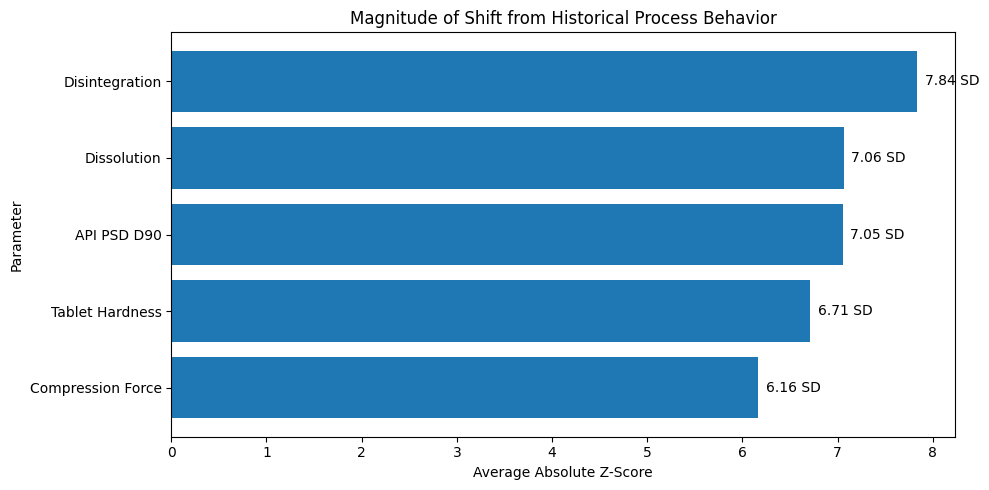

In [37]:
plot_df = investigation_table.sort_values(
    "Avg_Absolute_Z",
    ascending=True
)

plt.figure(figsize=(10, 5))

plt.barh(
    plot_df["Parameter"],
    plot_df["Avg_Absolute_Z"]
)

plt.xlabel("Average Absolute Z-Score")
plt.ylabel("Parameter")
plt.title("Magnitude of Shift from Historical Process Behavior")

for i, value in enumerate(plot_df["Avg_Absolute_Z"]):
    plt.text(
        value + 0.08,
        i,
        f"{value:.2f} SD",
        va="center"
    )

plt.tight_layout()
plt.show()

## 10. Final Integrated CPV Dashboard
Present management KPIs, automated assessment, dissolution trend, standardized shift severity, and the multivariate signal matrix in one view.


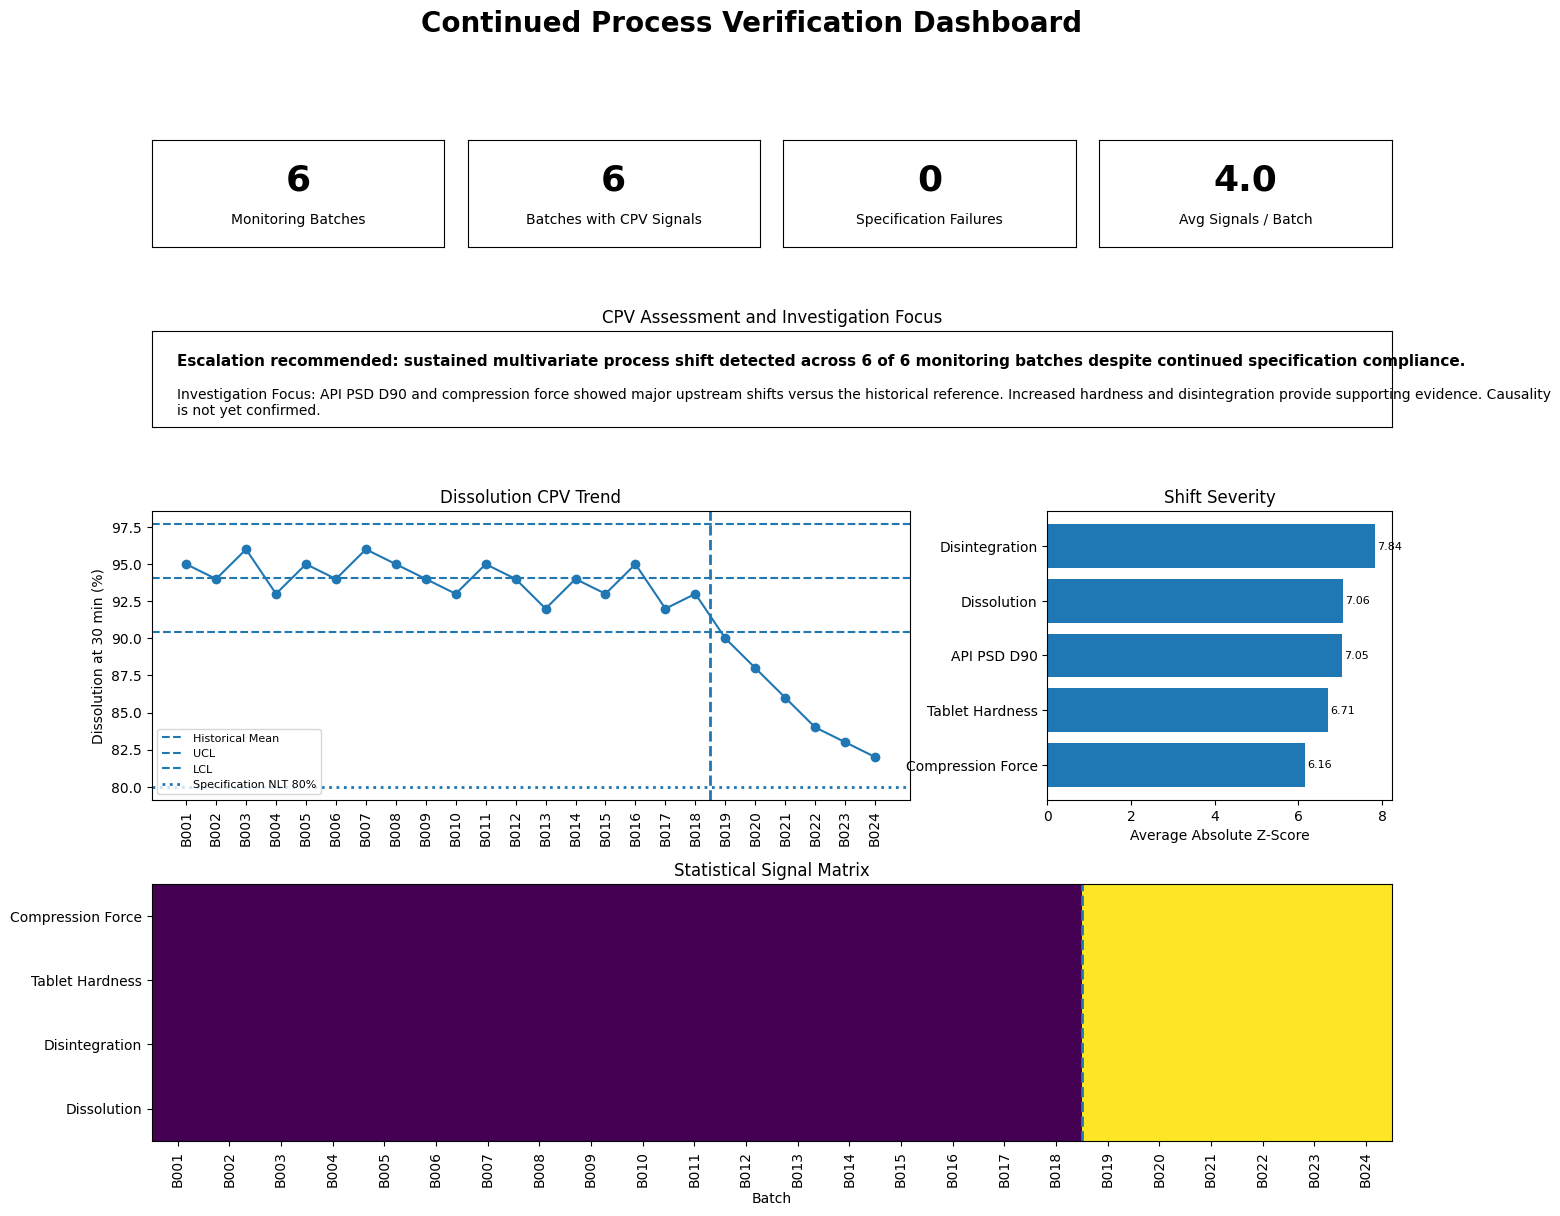

In [38]:
driver_message = (
    "Investigation Focus: API PSD D90 and compression force showed major "
    "upstream shifts versus the historical reference. Increased hardness "
    "and disintegration provide supporting evidence. Causality is not yet confirmed."
)

fig = plt.figure(figsize=(16, 13))

outer = fig.add_gridspec(
    4, 1,
    height_ratios=[1, 0.9, 2.7, 2.4],
    hspace=0.45
)

# =================================================
# 1. KPI CARDS
# =================================================

kpi_grid = outer[0].subgridspec(1, 4, wspace=0.08)

kpi_values = [
    total_monitoring,
    flagged_batches,
    spec_failures,
    round(avg_signal_count, 1)
]

kpi_titles = [
    "Monitoring Batches",
    "Batches with CPV Signals",
    "Specification Failures",
    "Avg Signals / Batch"
]

for i in range(4):
    ax = fig.add_subplot(kpi_grid[0, i])

    ax.text(
        0.5, 0.62,
        str(kpi_values[i]),
        ha="center",
        va="center",
        fontsize=26,
        fontweight="bold"
    )

    ax.text(
        0.5, 0.25,
        kpi_titles[i],
        ha="center",
        va="center",
        fontsize=10
    )

    ax.set_xticks([])
    ax.set_yticks([])


# =================================================
# 2. AUTOMATED ASSESSMENT + INVESTIGATION FOCUS
# =================================================

ax_text = fig.add_subplot(outer[1])

ax_text.text(
    0.02, 0.68,
    cpv_conclusion,
    fontsize=11,
    fontweight="bold",
    va="center",
    wrap=True
)

ax_text.text(
    0.02, 0.25,
    driver_message,
    fontsize=10,
    va="center",
    wrap=True
)

ax_text.set_title("CPV Assessment and Investigation Focus")
ax_text.set_xticks([])
ax_text.set_yticks([])


# =================================================
# 3. DISSOLUTION TREND + SHIFT SEVERITY
# =================================================

middle = outer[2].subgridspec(
    1, 2,
    width_ratios=[2.2, 1],
    wspace=0.25
)

# Dissolution trend
ax1 = fig.add_subplot(middle[0, 0])

ax1.plot(
    df["Batch_ID"],
    df["Dissolution_30min_pct"],
    marker="o"
)

ax1.axhline(
    historical_mean,
    linestyle="--",
    label="Historical Mean"
)

ax1.axhline(
    ucl,
    linestyle="--",
    label="UCL"
)

ax1.axhline(
    lcl,
    linestyle="--",
    label="LCL"
)

ax1.axhline(
    80,
    linestyle=":",
    linewidth=2,
    label="Specification NLT 80%"
)

ax1.axvline(
    x=17.5,
    linestyle="--",
    linewidth=2
)

ax1.set_ylabel("Dissolution at 30 min (%)")
ax1.set_title("Dissolution CPV Trend")
ax1.tick_params(axis="x", rotation=90)
ax1.legend(fontsize=8)


# Shift severity
ax_shift = fig.add_subplot(middle[0, 1])

plot_df = investigation_table.sort_values(
    "Avg_Absolute_Z",
    ascending=True
)

ax_shift.barh(
    plot_df["Parameter"],
    plot_df["Avg_Absolute_Z"]
)

ax_shift.set_xlabel("Average Absolute Z-Score")
ax_shift.set_title("Shift Severity")

for i, value in enumerate(plot_df["Avg_Absolute_Z"]):
    ax_shift.text(
        value + 0.05,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=8
    )


# =================================================
# 4. SIGNAL MATRIX
# =================================================

ax2 = fig.add_subplot(outer[3])

ax2.imshow(
    signal_matrix.T,
    aspect="auto"
)

ax2.set_xticks(range(len(df)))
ax2.set_xticklabels(
    df["Batch_ID"],
    rotation=90
)

ax2.set_yticks(range(4))
ax2.set_yticklabels([
    "Compression Force",
    "Tablet Hardness",
    "Disintegration",
    "Dissolution"
])

ax2.axvline(
    x=17.5,
    linestyle="--",
    linewidth=2
)

ax2.set_xlabel("Batch")
ax2.set_title("Statistical Signal Matrix")


# =================================================
# DASHBOARD TITLE
# =================================================

fig.suptitle(
    "Continued Process Verification Dashboard",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

plt.show()

## 11. Export
Save the final dashboard as a high-resolution PNG for reporting and portfolio use.


In [39]:
fig.savefig(
    "CPV_Dashboard_V1.png",
    dpi=300,
    bbox_inches="tight"
)